In [1]:
import numpy as np
from scripts.train_vbe_kfold import train_vbe
import torch
import matplotlib.pyplot as plt

In [2]:
_, params = np.load("data/coupled_oscillator.npz").values()
dmat = torch.tensor(np.load("data/co_dmat.npz")["dmat"], dtype=torch.float32)
dmat /= dmat.max()

In [3]:
vbe = train_vbe(dmat.pow(2), "coupled oscillator", epochs=200)

100%|██████████| 200/200 [02:29<00:00,  1.34it/s]


In [4]:
p = vbe.squeezing_layer.equivalent_dropout_rate()
embedding = vbe.embed(dmat.to(vbe.device))

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.bar(range(100), sorted(p.max(1).values.detach().cpu(), reverse=True))
plt.xlabel("Latent coordinate index")
plt.ylabel("Maximum EDR")
plt.yscale("log")
plt.title("Components' relevance")

for i, param in enumerate(params.T, 1):
    plt.subplot(1, 3, i + 1)
    plt.scatter(*embedding.T, c=param)
    plt.xlabel("Embedding component #1")
    plt.ylabel("Embedding component #2")
    plt.title(f"Embedding, colored by E{i}")
    plt.colorbar()

plt.tight_layout()
plt.show()

AttributeError: 'VBE' object has no attribute 'embed'

In [5]:
_, params = np.load("data/quantum_ho.npz").values()
dmat = torch.tensor(np.load("data/qho_dmat.npz")["dmat"], dtype=torch.float32)
dmat[dmat.isnan()] = dmat.nanmean()
dmat /= dmat.max()

In [6]:
pbmds = train_pbmds(dmat.pow(2), "quantum harmonic oscillator", epochs=200)

epoch,▁▁▁▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇███
loss,█▄▃▄▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
reg,█▇▅▅▄▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
relevant dims count,██████████▄▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,200
loss,0.00881
reg,0.0011
relevant dims count,1


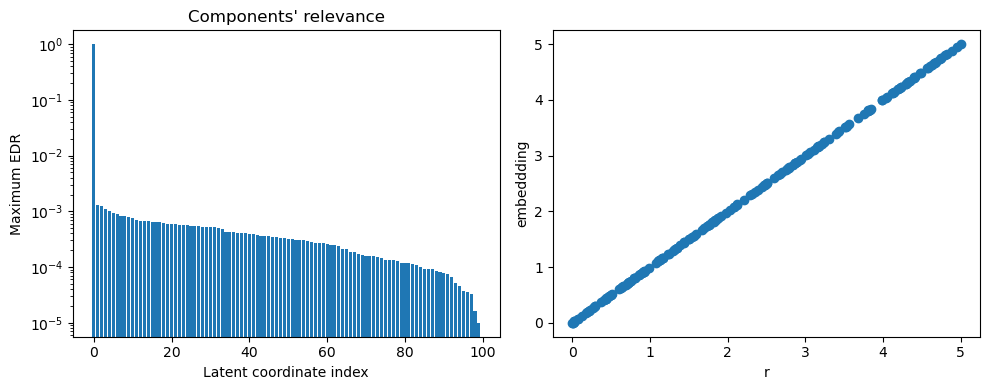

In [7]:
p = pbmds.squeezing_layer.equivalent_dropout_rate()
embedding = pbmds.embedding(dmat.to(pbmds.device))
d = embedding.shape[1]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(range(100), sorted(p.max(1).values.detach().cpu(), reverse=True))
plt.xlabel("Latent coordinate index")
plt.ylabel("Maximum EDR")
plt.yscale("log")
plt.title("Components' relevance")

plt.subplot(1, 2, 2)
plt.scatter(params[:, 0], params[:, 0])
plt.xlabel("r")
plt.ylabel("embeddding")

plt.tight_layout()
plt.show()